# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- Does generative AI exposure disproportionately impact women-dominated occupations in Australia?
- Research released by the ILO and Australian Government this week indicate that women's occupations are more likely to be impacted by generative AI exposure. The Australian Government's research uses AI Occupational Exposure (AIOE) scores developed by Felten et al (2021), and Anthropic's observed exposure scores against headcount employment by industry.
- My analysis will focus on Australia, using workforce data as at 2025
- International Labour Organisation AI occupational exposure index and ILOSTAT, Employment by sex and occupation filtered to Australia.

### **Project Summary**
- **Project Title:** Gendered impacts of generative AI in the Australian labour market
- **Student Name:** Sheena Pham 
- **Policy Relevance Statement:** If generative AI disruption is concentrated in female-dominated occupations, workforce transition policies risk widening existing labour market inequalities. Identifying where exposure falls is a first step toward developing evidence-based policy responses.

- **Central Hypothesis:** 

- H1: Female share is positively associated with GenAI exposure overall (aligned with the ILO and Australian Governemnt).
- H2: The relationship is driven by clerical occupations. Feminised workforce occupations show low exposure despite high female shares.


---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
**Primary Data Source:** 
- ILO AI Occupational Exposure (AIOE) Index, task-level exposure scores mapped to ISCO-08 occupations 

**Secondary Data Source:** 
- ILOSTAT, Employment by sex and occupation (ISCO-08), filtered to Australia 

**Variables Retrieved:** 
- AI exposure data: `isco08_1d`–`isco08_5d` (ISCO-08 occupation levels), `potential25`, `task_color` (AI exposure classification) 

- ILOSTAT employment data:`ref_area.label`, `sex.label`, `classif1.label` (age band), `classif2.label` (ISCO-08 occupation), `time`, `obs_value` (employment headcount) 

**Local Storage Path:** 
- `data/final_project/sheena-pham/ai_exposure_raw.csv`
-  `data/final_project/sheena-pham/employment_raw.csv`


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('../../../src/final_project/sheena-pham/basic').resolve()))
import data
df_exposure_raw, df_employment_raw = data.run()
df_exposure_raw.head()

Data acquired and saved to data/final_project/sheena-pham/ai_exposure_raw.csv and data/final_project/sheena-pham/employment_raw.csv


,isco08_1d,isco08_2d,isco08_3d,isco08_4d,isco08_5d,potential25,task_color
0,1 - Managers,"11 - Chief executives, senior officials and le...",111 - Legislators and senior officials,1111 - Legislators,( 0.34 ) - Presiding over or participating in ...,Not Exposed,Low
1,1 - Managers,"11 - Chief executives, senior officials and le...",111 - Legislators and senior officials,1111 - Legislators,"( 0.3575 ) - Determining, formulating and dire...",Not Exposed,Low
2,1 - Managers,"11 - Chief executives, senior officials and le...",111 - Legislators and senior officials,1111 - Legislators,"( 0.29 ) - Making, ratifying, amending or repe...",Not Exposed,Low
3,1 - Managers,"11 - Chief executives, senior officials and le...",111 - Legislators and senior officials,1111 - Legislators,( 0.25 ) - Serving on government administrativ...,Not Exposed,Low
4,1 - Managers,"11 - Chief executives, senior officials and le...",111 - Legislators and senior officials,1111 - Legislators,( 0.345 ) - Investigating matters of concern t...,Not Exposed,Low


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
**Merging Strategy:** 
- Task-level exposure scores are mapped from categorical labels ("Not Exposed" → "Exposed: Gradient 4") to a 0-5 numeric scale and averaged up to the 2-digit ISCO-08 occupation level. 
- Employment counts are filtered to Australia, restricted to Female/Male rows, and pivoted wide by sex for the latest available year. 
- The two are combined with an inner join on `isco08_code`.

**Pre-cleaned Observations:** 
- 3,265 task-level exposure records and 622 employment records (Australia, 2-digit ISCO-08, by sex) before aggregation.

**Final Dataset Observations:** 
- 38 clean rows (one per 2-digit ISCO-08 occupation) and 10 columns, with no missing exposure or employment values after the merge.

 **Clean Data Path:** 
 - `data/final_project/sheena-pham/processed_gender_ai_exposure.csv`


In [2]:
import manipulate
df_clean = manipulate.run()
df_clean.head()


Data processed and saved to data/final_project/sheena-pham/processed_gender_ai_exposure.csv with shape (38, 10)


,isco08_code,isco08_label,exposure_score,n_tasks,employment_female,employment_male,year,employment_total,female_share,is_clerical
0,41,General and keyboard clerks,4.714286,28,293.280,69.042,2025,362.322,0.809446,True
1,43,Numerical and material recording clerks,3.838710,31,332.228,158.806,2025,491.034,0.676589,True
2,25,Information and communications technology prof...,3.821429,56,92.327,309.407,2025,401.734,0.229821,False
3,44,Other clerical support workers,3.735294,34,50.932,32.903,2025,83.835,0.607527,True
4,42,Customer services clerks,3.700000,70,221.355,78.790,2025,300.145,0.737494,True


## Architecture Overview


```mermaid
flowchart TD
    A["ILO_AI_exposure.xlsx<br/><small>task-level exposure, ISCO-08 1d-5d</small>"]
    B["occupation_data.csv<br/><small>ILOSTAT employment by sex, ISCO-08</small>"]
    D["data.py<br/><small>load_ai_exposure() · load_employment()<br/>filter to Australia, 2-digit ISCO-08, Female/Male</small>"]
    E["ai_exposure_raw.csv"]
    F["employment_raw.csv"]
    M["manipulate.py<br/><small>process_exposure() · process_employment()<br/>inner join on isco08_code</small>"]
    P["processed_gender_ai_exposure.csv<br/><small>38 rows x 10 cols</small>"]
    G["graph.py<br/><small>Fig 1: scatter + regplot (H1)<br/>Fig 2: ranked barh (H2)</small>"]
    R["model.py<br/><small>OLS: exposure_score ~ female_share</small>"]
    GO["2 matplotlib figures"]
    RO["Regression summary"]

    A --> D
    B --> D
    D --> E
    D --> F
    E --> M
    F --> M
    M --> P
    P --> G
    P --> R
    G --> GO
    R --> RO

## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
**Figure 1 Key Takeaway:** 
- Female share and GenAI exposure are positively related overall (the fitted line slopes up), but the two most female-dominated occupation groups sit at opposite ends of the exposure scale: clerical occupations (e.g. general and keyboard clerks, 81% female) cluster in the high-exposure top-right, while health, personal care and teaching occupations (e.g. personal care workers, 80% female; personal service workers, 69% female) sit in the low-exposure bottom-right despite comparable or higher female shares.

**Figure 2 Key Takeaway:** 
- Ranking occupations by female share and shading by exposure shows that occupations above the 50% female-share line are not uniformly high-exposure the bars split into a small cluster of dark (high-exposure) clerical bars and a larger cluster of light (low-exposure) care/service/teaching bars, visually reinforcing that female-dominance alone does not predict exposure.


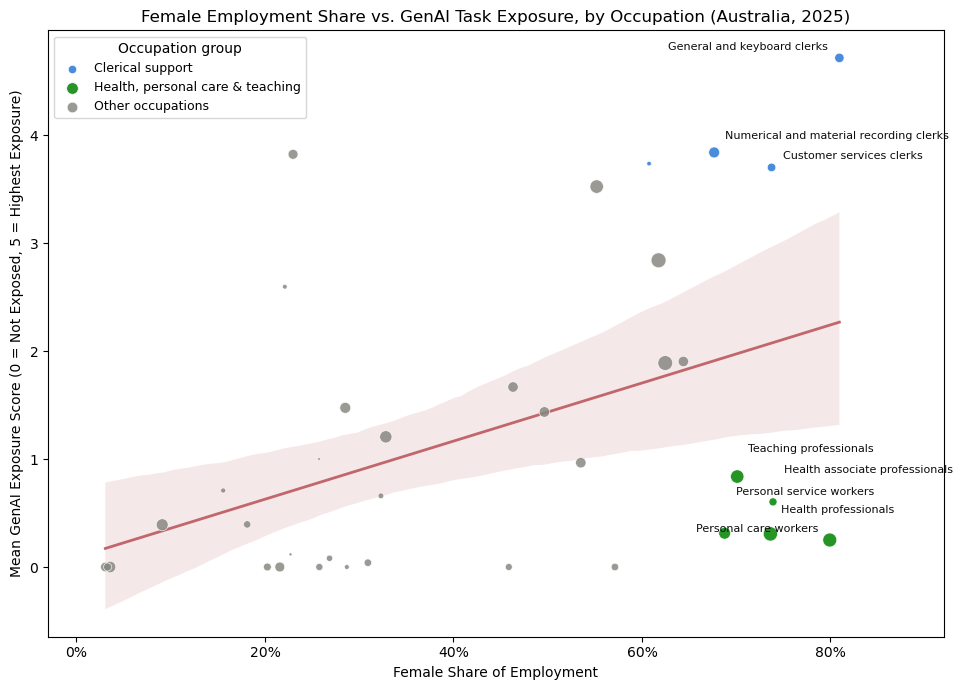

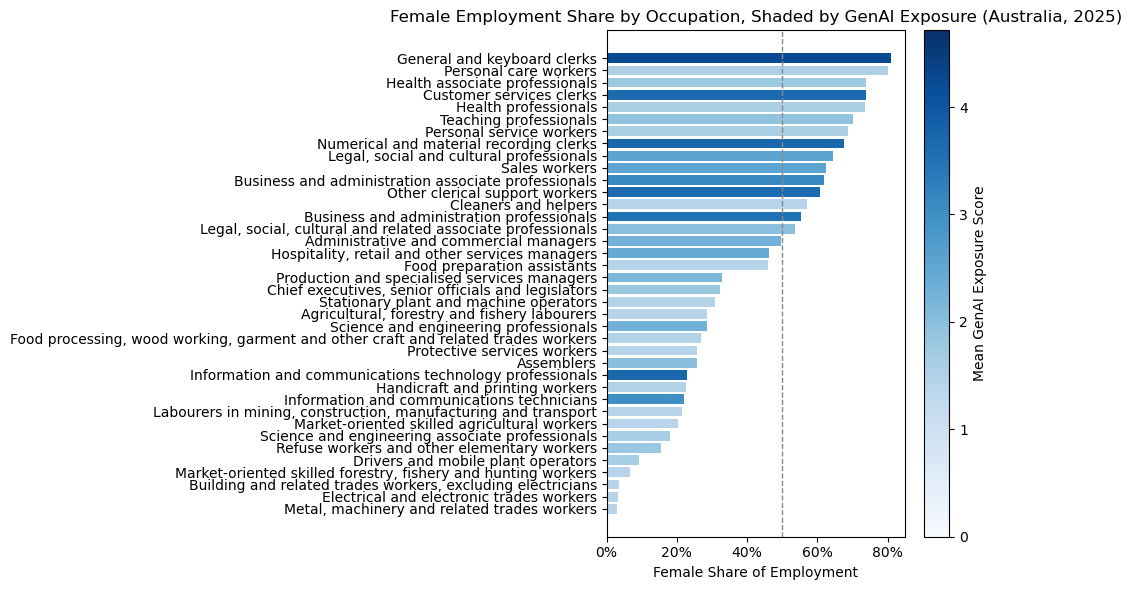

In [3]:
import graph
graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
 **Model Type:** 
- Cross-sectional OLS, exposure_score ~ female_share, across the 38 ISCO-08 2-digit occupation groups in Australia.

**Model Fit Metrics:** 
- R-squared = 0.216, Number of Observations = 38.

**Coefficient of Primary Variable (female_share):**
-  Coefficient: 2.6905, Std. Err: 0.854, T-stat: 3.151 (p-value: 0.003).

**Statistical Significance:** 
- female_share is significant at the 1% level (p = 0.003); the intercept is not distinguishable from zero (p = 0.826). This supports **H1**: a 10 percentage-point increase in an occupation's female employment share is associated with roughly a 0.27-point increase in mean GenAI exposure score (on the 0–5 scale).

**Key Conclusion:** 

- The results supports H1, but Figure 1 and the underlying group averages show this relationship is not uniform across female-dominated occupations.
-  Clerical occupations average 71% female share with a mean exposure score of 4.00, while health, personal care and teaching occupations average an even higher 73% female share but a mean exposure score of only 0.46 nearly the reverse pattern despite similar female shares. 
- This is consistent with my hypothesis 2, the aggregate positive association is driven largely by clerical occupations, not by female-dominated occupations generally. 
- An interaction test of female_share × is_clerical points the same direction but is not statistically significant, likely because only 4 of the 38 occupations are classified as clerical. This should be read as descriptive rather than confirmatory support for H2.


In [4]:
import model
summary = model.run()


=== Regression Results Summary ===
                            OLS Regression Results                            
Dep. Variable:         exposure_score   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     9.931
Date:                Fri, 17 Jul 2026   Prob (F-statistic):            0.00327
Time:                        18:53:05   Log-Likelihood:                -61.769
No. Observations:                  38   AIC:                             127.5
Df Residuals:                      36   BIC:                             130.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    